In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 8
fig_height = 5
fig_format = 'png'
fig_dpi = 300
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RTpccGh5c2ljcy1pZ2NzZS1tYWluXHBoeXNpY3MtaWdjc2Utbm90ZXNcY2hhcHRlcnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1744091814.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\

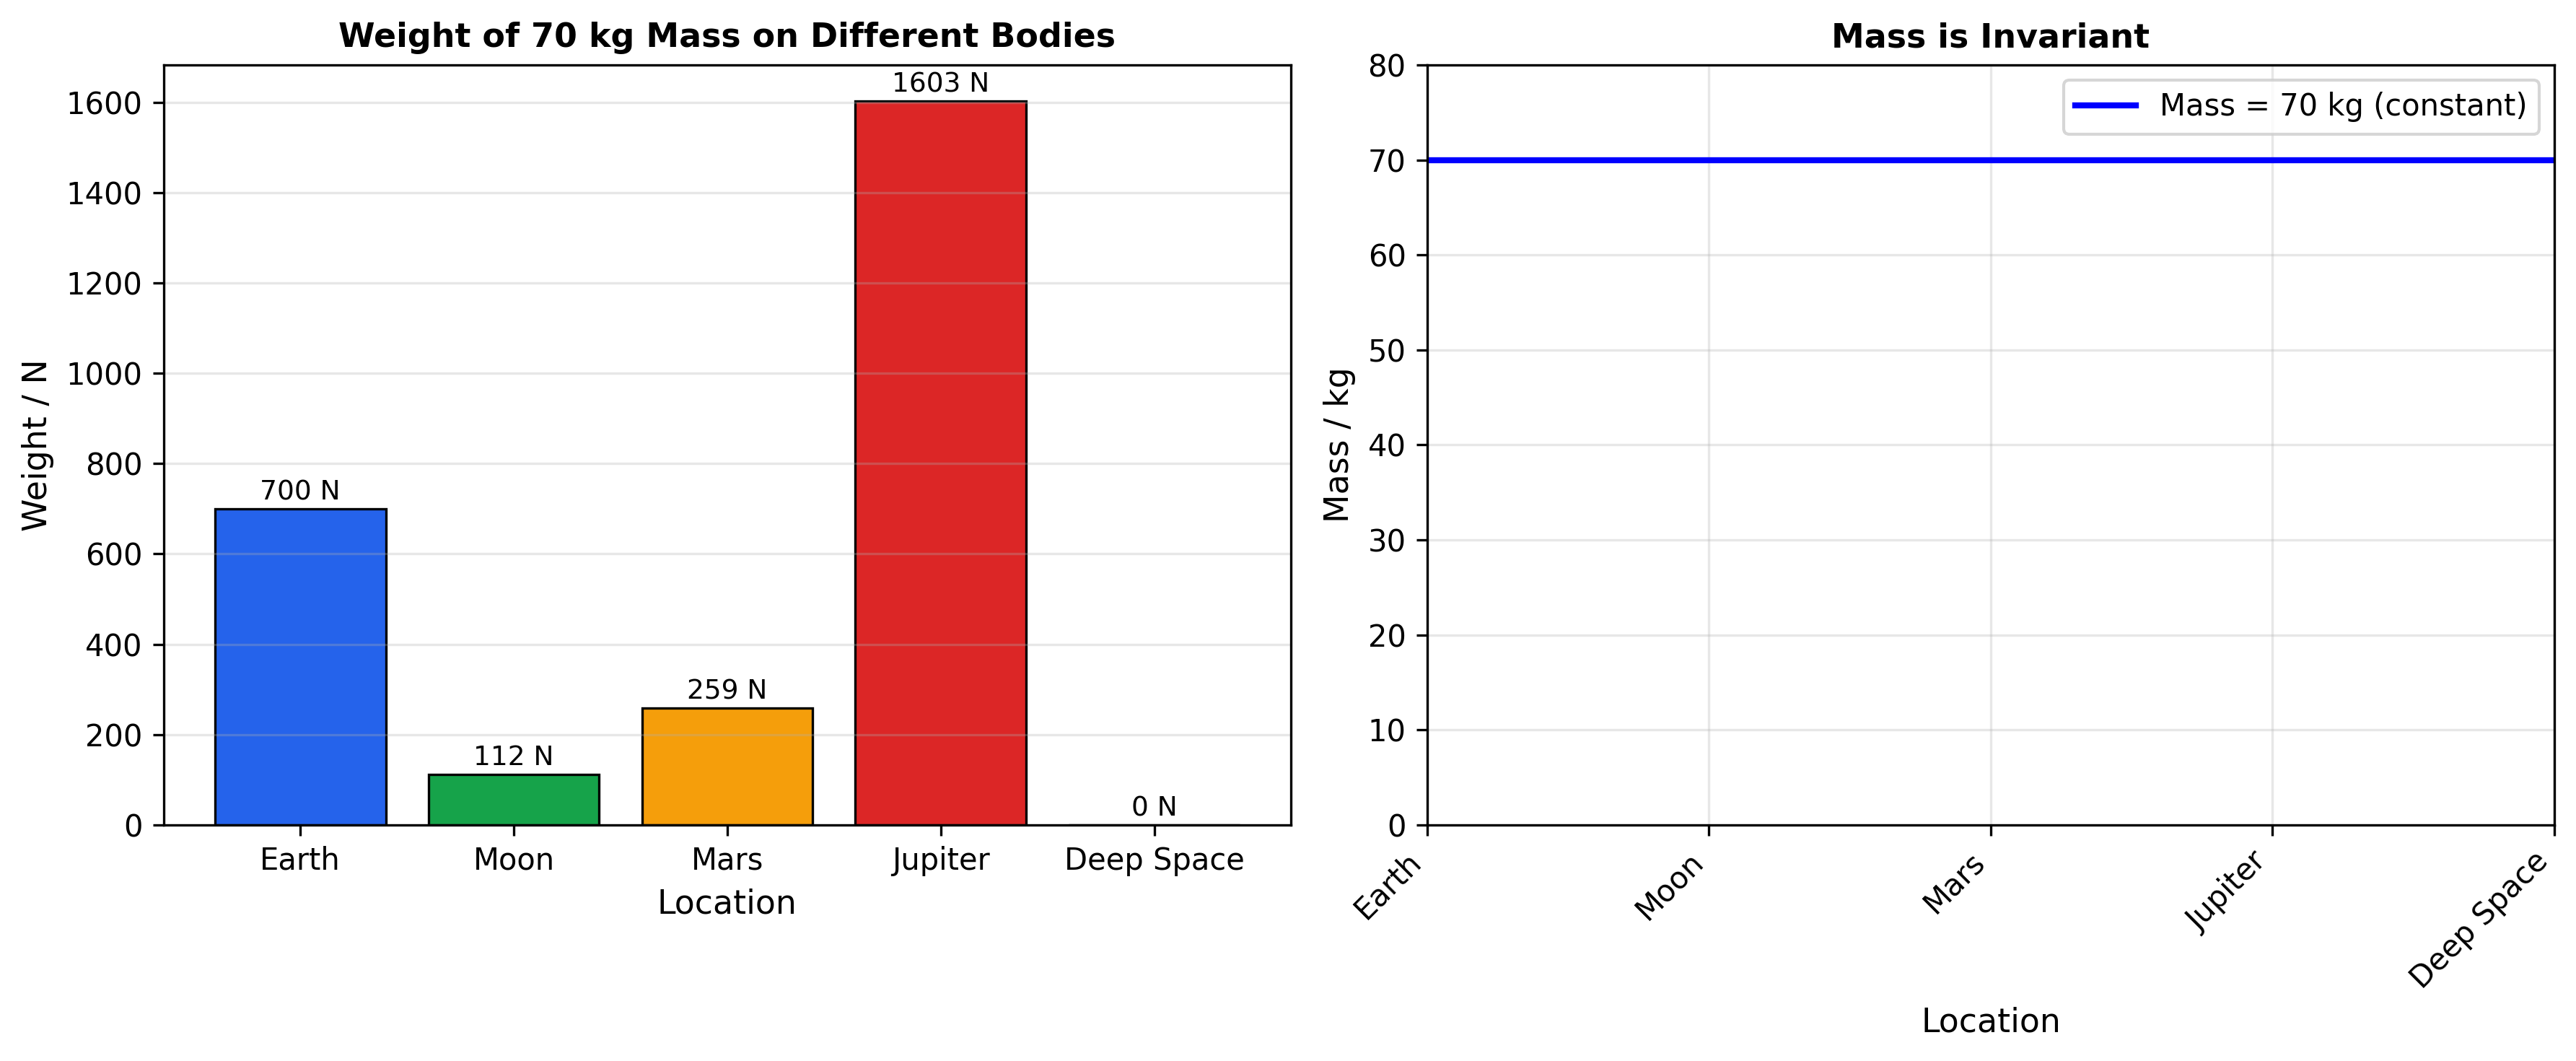

In [2]:
#| label: fig-mass-vs-weight-planets
#| fig-cap: 'Mass vs weight: how weight changes with gravitational field strength while mass stays constant'
#| fig-align: center
#| warning: false

import numpy as np
import matplotlib.pyplot as plt

# Data for different celestial bodies
bodies = ['Earth', 'Moon', 'Mars', 'Jupiter', 'Deep Space']
g_values = [10, 1.6, 3.7, 22.9, 0]  # N/kg
mass = 70  # kg (constant)

# Calculate weights
weights = [mass * g for g in g_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: Weight on different bodies
colors = ['#2563eb', '#16a34a', '#f59e0b', '#dc2626', '#6b7280']
bars = ax1.bar(bodies, weights, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Location', fontsize=11)
ax1.set_ylabel('Weight / N', fontsize=11)
ax1.set_title('Weight of 70 kg Mass on Different Bodies', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, w in zip(bars, weights):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             f'{w:.0f} N', ha='center', fontsize=9)

# Horizontal line: constant mass
ax2.axhline(y=mass, color='blue', linewidth=2, label=f'Mass = {mass} kg (constant)')
ax2.set_xlabel('Location', fontsize=11)
ax2.set_ylabel('Mass / kg', fontsize=11)
ax2.set_title('Mass is Invariant', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 80)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xticks(range(len(bodies)))
ax2.set_xticklabels(bodies, rotation=45, ha='right')

plt.tight_layout()
plt.show()

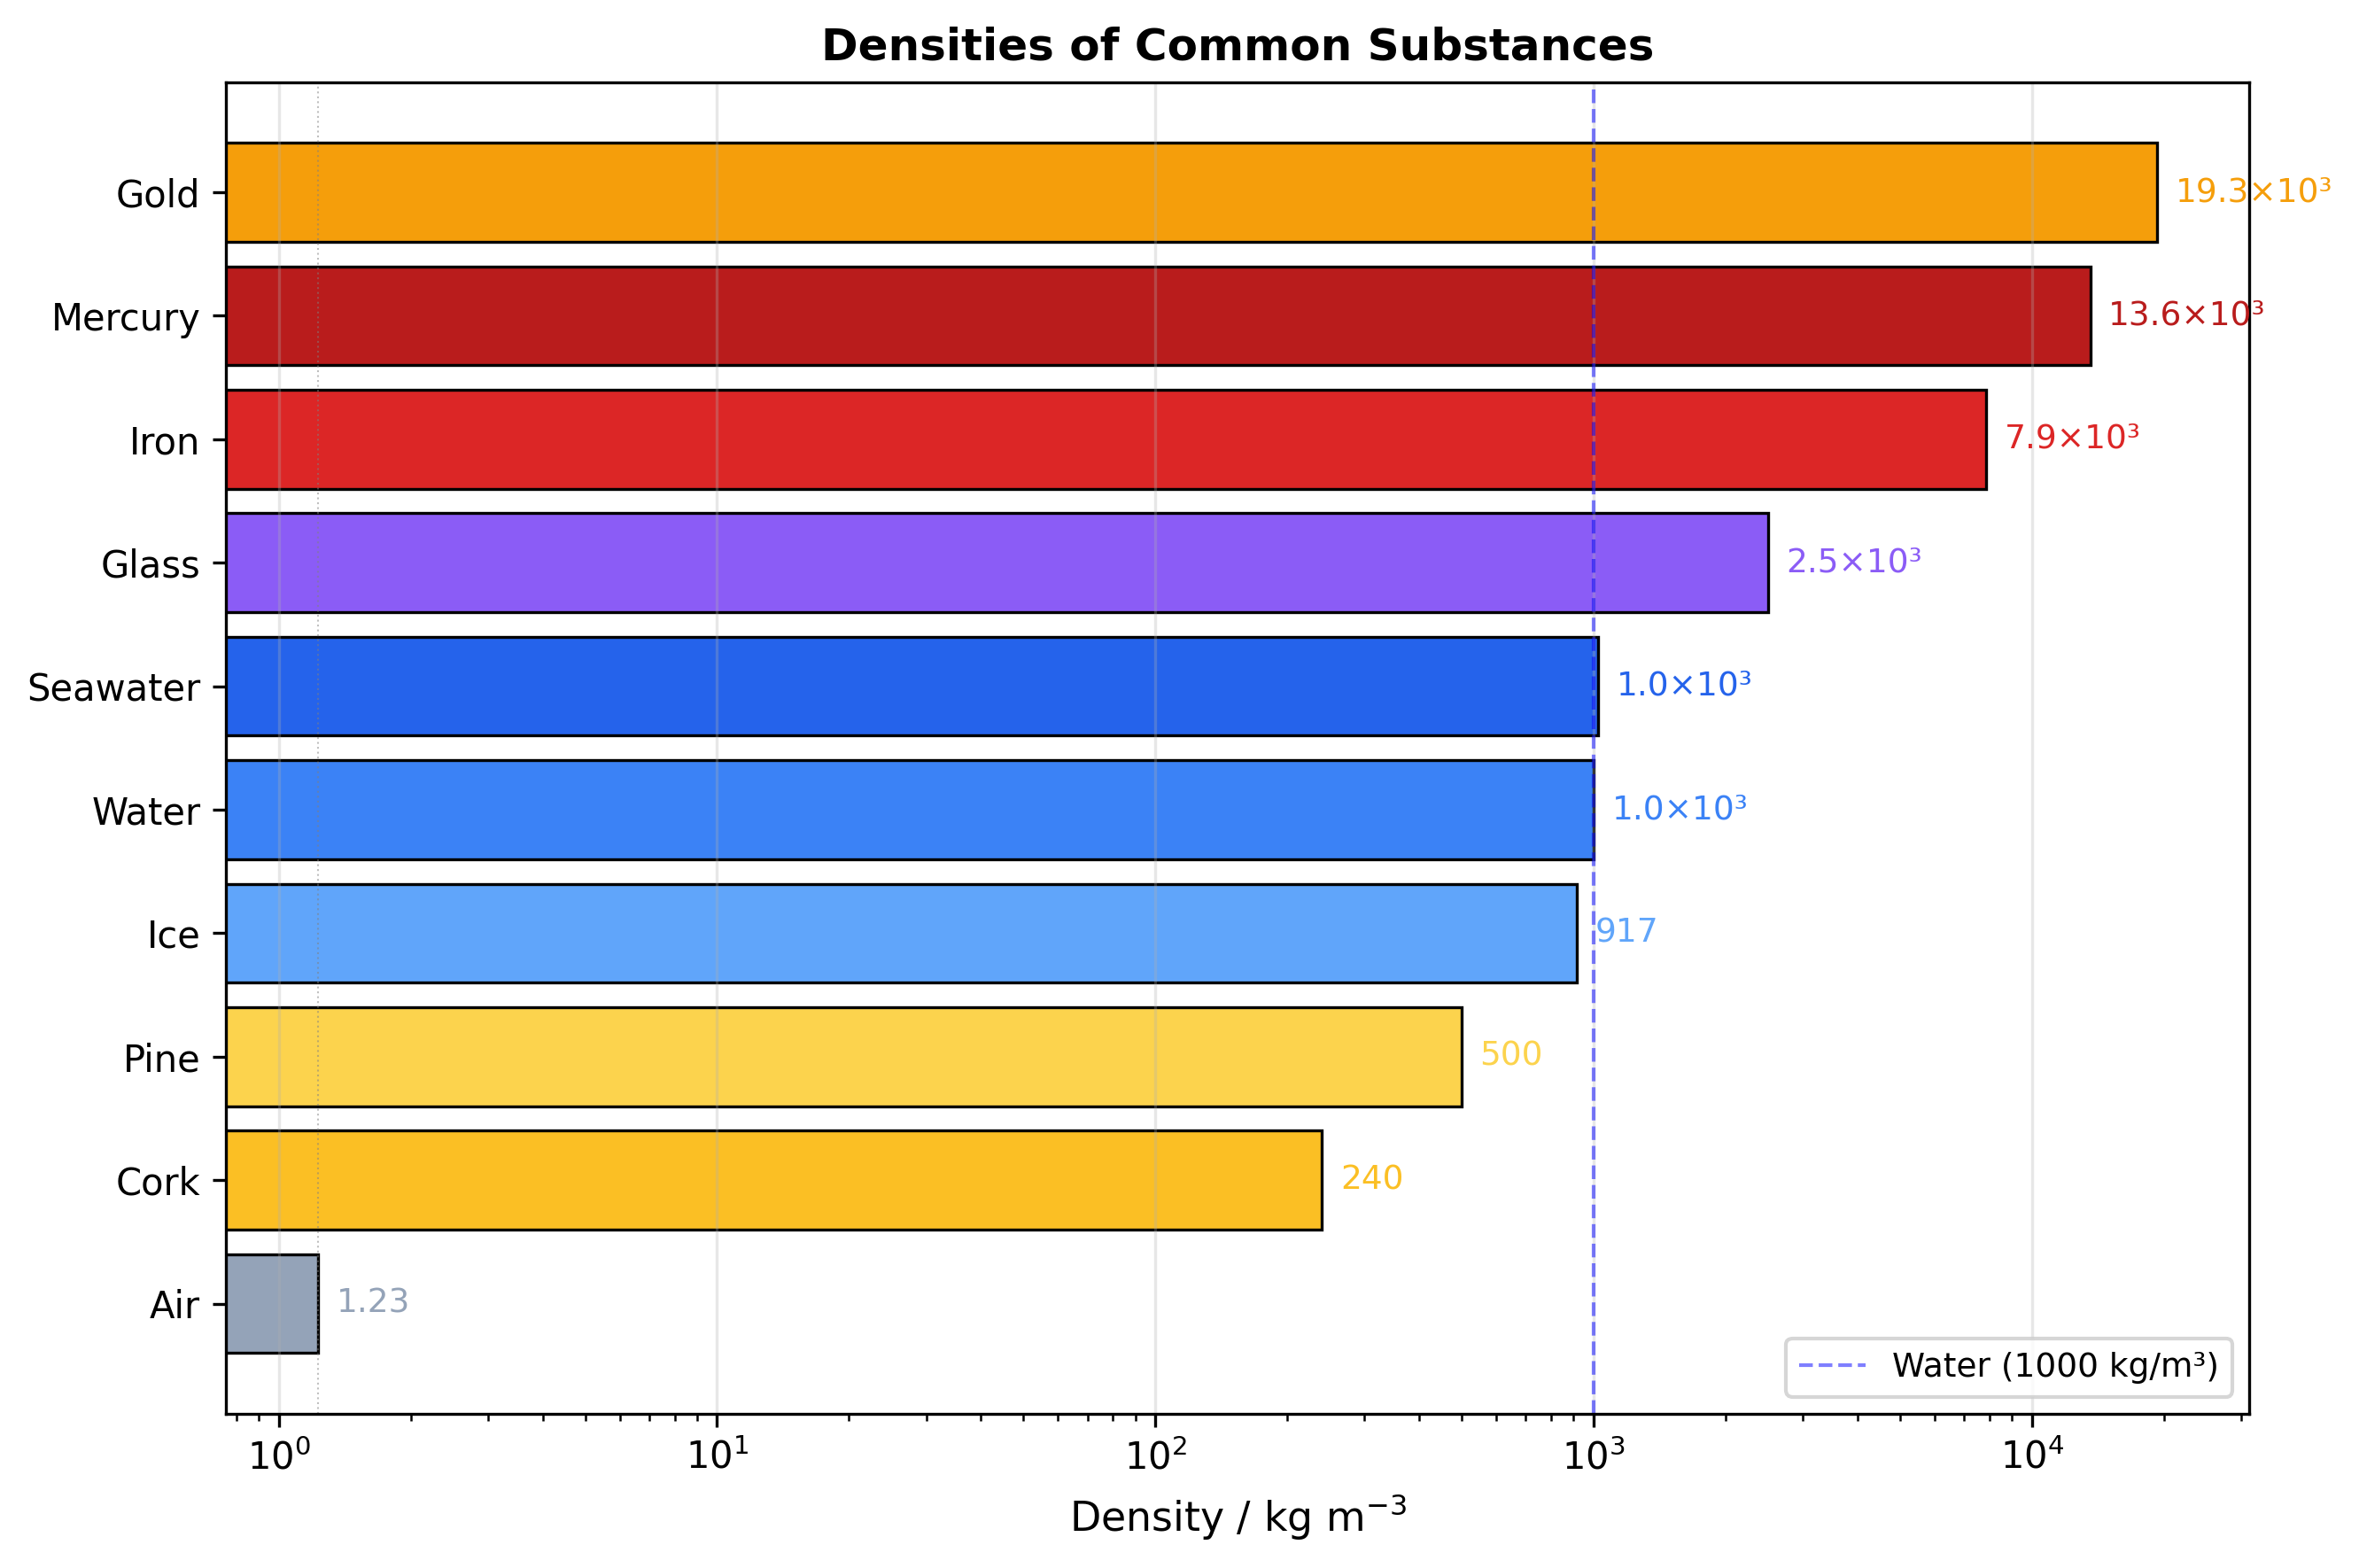

In [3]:
#| label: fig-density-comparison
#| fig-cap: Density comparison of common substances (logarithmic scale)
#| fig-align: center
#| warning: false

import numpy as np
import matplotlib.pyplot as plt

# Density data (kg/m³)
substances = ['Air', 'Cork', 'Pine', 'Ice', 'Water', 'Seawater', 'Glass', 'Iron', 'Mercury', 'Gold']
densities = [1.23, 240, 500, 917, 1000, 1025, 2500, 7870, 13600, 19300]
colors = ['#94a3b8', '#fbbf24', '#fcd34d', '#60a5fa', '#3b82f6', '#2563eb', 
          '#8b5cf6', '#dc2626', '#b91c1c', '#f59e0b']

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(substances))

# Horizontal bar chart with log scale for better visualization
ax.barh(y_pos, densities, color=colors, edgecolor='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(substances, fontsize=10)
ax.set_xlabel('Density / kg m$^{-3}$', fontsize=11)
ax.set_title('Densities of Common Substances', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xscale('log')  # Log scale to show wide range clearly

# Add value labels
for i, (d, c) in enumerate(zip(densities, colors)):
    label = f'{d}' if d < 1000 else f'{d/1000:.1f}×10³'
    ax.text(d * 1.1, i, label, va='center', fontsize=9, color=c)

# Reference lines for water and air
ax.axvline(x=1000, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='Water (1000 kg/m³)')
ax.axvline(x=1.23, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18588\3897777902.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = Circle((x, -1.5), 0.8, color='white', edgecolor='gray', linewidth=1, alpha=0.9)


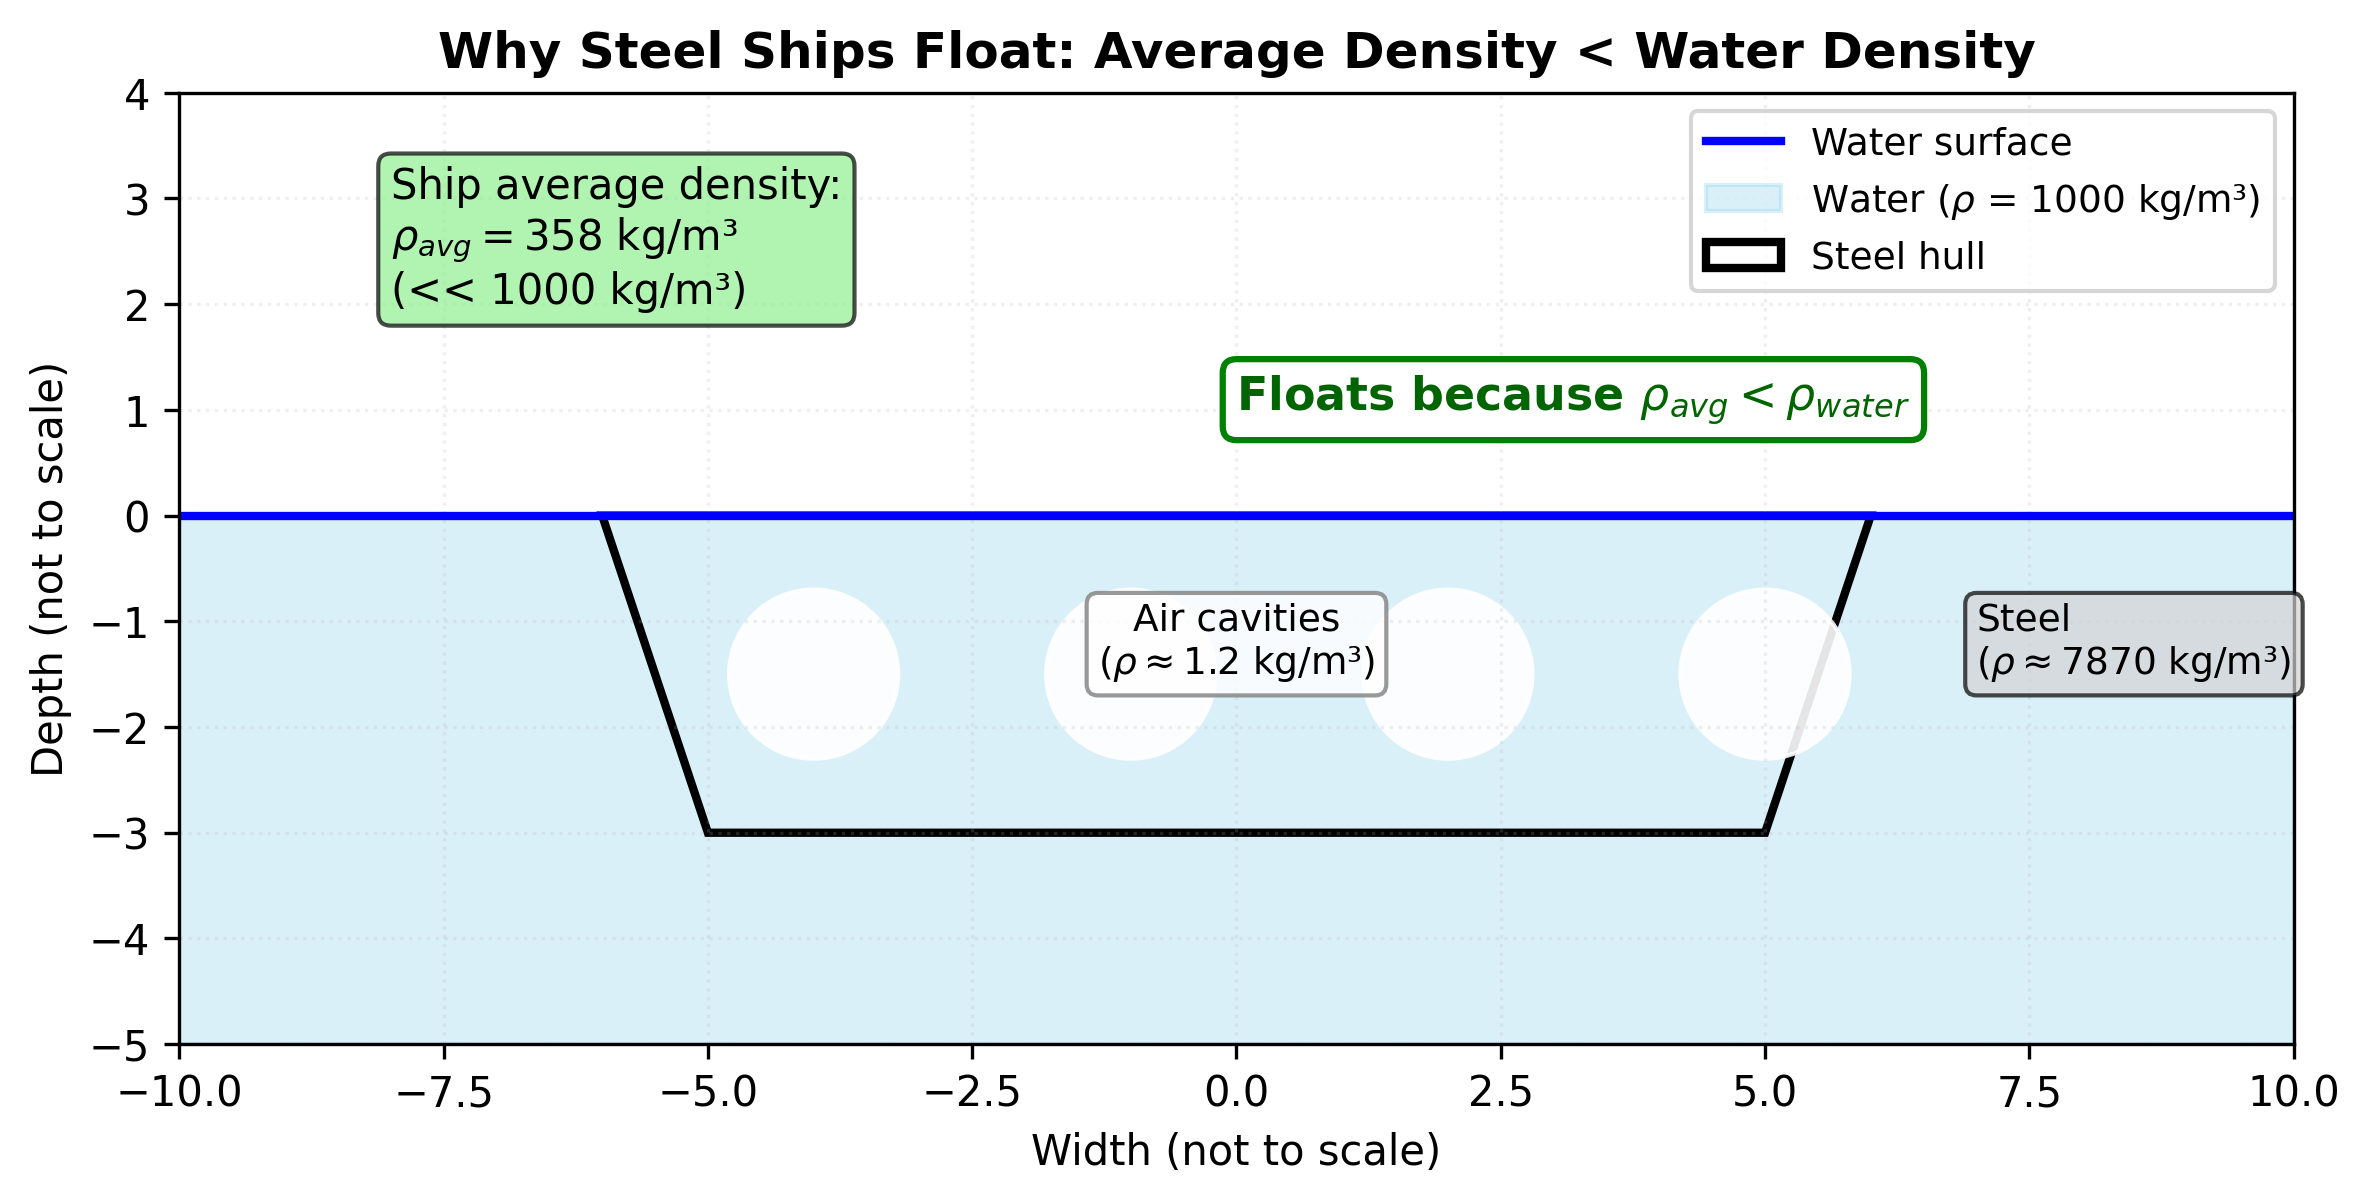

In [4]:
#| label: fig-ship-buoyancy
#| fig-cap: 'Why ships float: average density concept with steel hull and air cavities'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(8, 6))

# Draw water surface
ax.axhline(y=0, color='blue', linewidth=2, label='Water surface')
ax.fill_between([-10, 10], -5, 0, color='skyblue', alpha=0.3, label='Water ($\\rho$ = 1000 kg/m³)')

# Draw ship hull (simplified trapezoid)
hull = plt.Polygon([[-6, 0], [-5, -3], [5, -3], [6, 0]], 
                   closed=True, fill=False, edgecolor='black', linewidth=2, label='Steel hull')
ax.add_patch(hull)

# Draw air cavities inside hull (white circles)
for x in [-4, -1, 2, 5]:
    circle = Circle((x, -1.5), 0.8, color='white', edgecolor='gray', linewidth=1, alpha=0.9)
    ax.add_patch(circle)

# Label components
ax.text(0, -1.5, 'Air cavities\n($\\rho \\approx 1.2$ kg/m³)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))
ax.text(7, -1.5, 'Steel\n($\\rho \\approx 7870$ kg/m³)', ha='left', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# Calculate and display average density
total_mass = 7.68e7  # kg
total_volume = 214400  # m³
avg_density = total_mass / total_volume
ax.text(-8, 2, f'Ship average density:\n$\\rho_{{avg}} = {avg_density:.0f}$ kg/m³\n(<< 1000 kg/m³)', 
        fontsize=10, ha='left', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Floating condition annotation
ax.text(0, 1, 'Floats because $\\rho_{avg} < \\rho_{water}$', 
        fontsize=11, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='green', linewidth=1.5))

ax.set_xlim(-10, 10)
ax.set_ylim(-5, 4)
ax.set_xlabel('Width (not to scale)', fontsize=10)
ax.set_ylabel('Depth (not to scale)', fontsize=10)
ax.set_title('Why Steel Ships Float: Average Density < Water Density', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2, linestyle=':')
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

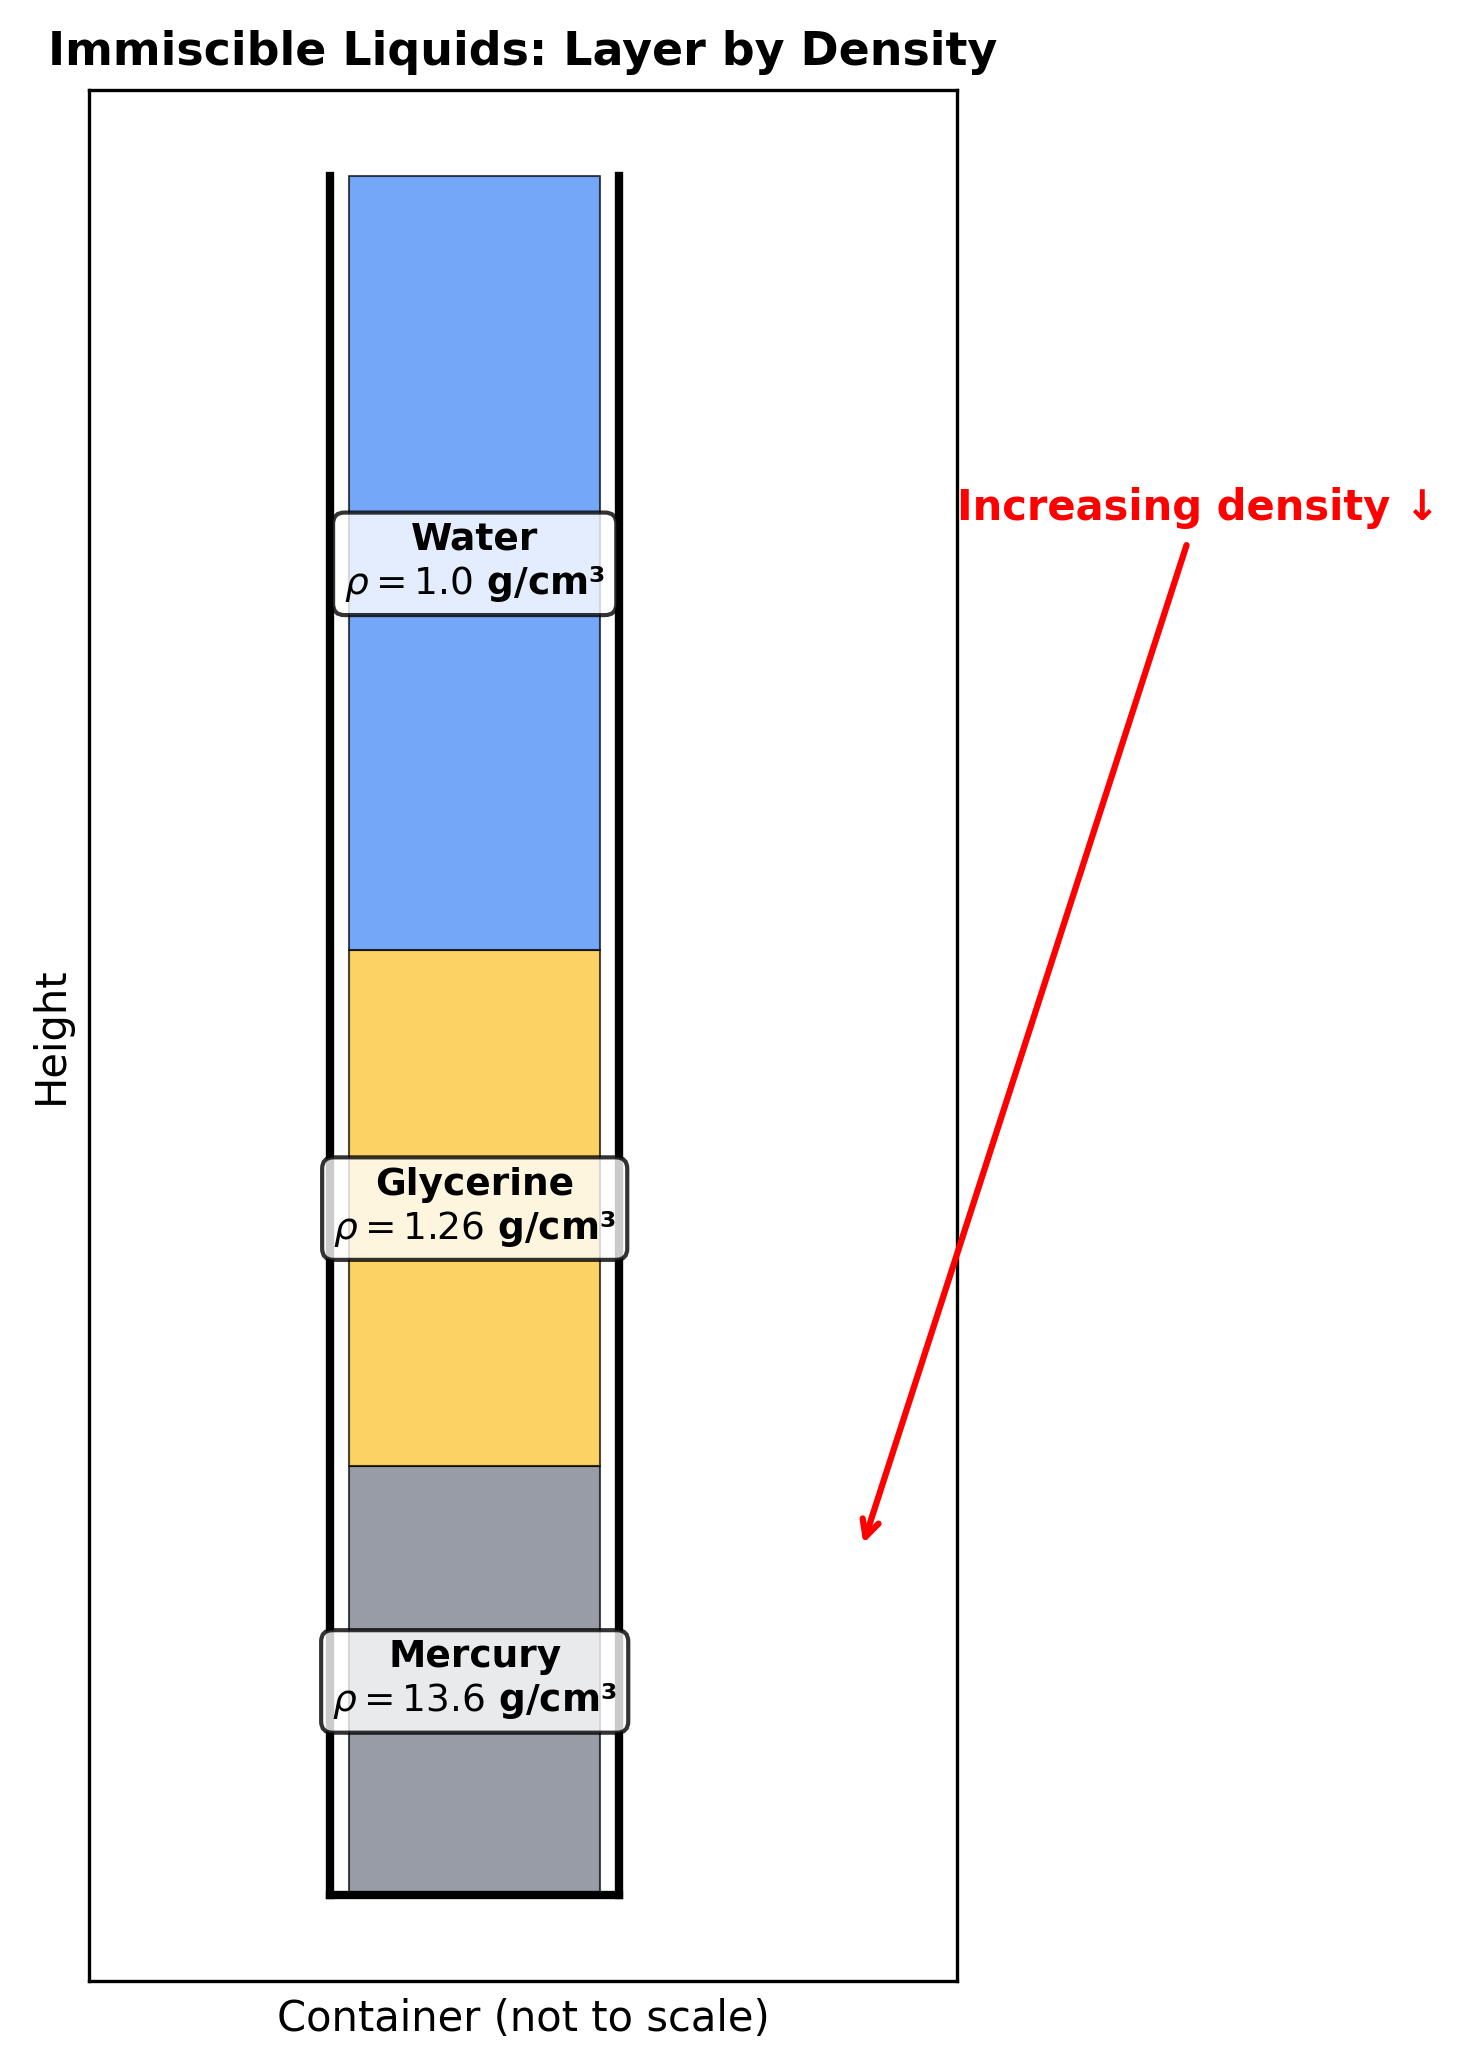

In [5]:
#| label: fig-immiscible-liquids
#| fig-cap: 'Immiscible liquids layering by density: mercury, glycerine, water'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 7))

# Cylinder outline
cylinder_width = 3
cylinder_height = 10
ax.plot([-cylinder_width/2, -cylinder_width/2], [0, cylinder_height], 'k-', linewidth=2)
ax.plot([cylinder_width/2, cylinder_width/2], [0, cylinder_height], 'k-', linewidth=2)
ax.plot([-cylinder_width/2, cylinder_width/2], [0, 0], 'k-', linewidth=2)

# Liquid layers (bottom to top: highest to lowest density)
layers = [
    {'name': 'Mercury', 'rho': 13.6, 'color': '#6b7280', 'height': 2.5, 'y0': 0},
    {'name': 'Glycerine', 'rho': 1.26, 'color': '#fbbf24', 'height': 3.0, 'y0': 2.5},
    {'name': 'Water', 'rho': 1.00, 'color': '#3b82f6', 'height': 4.5, 'y0': 5.5}
]

for layer in layers:
    y1 = layer['y0']
    y2 = y1 + layer['height']
    ax.fill_between([-cylinder_width/2 + 0.2, cylinder_width/2 - 0.2], y1, y2, 
                    color=layer['color'], alpha=0.7, edgecolor='black', linewidth=0.5)
    # Label
    ax.text(0, (y1 + y2)/2, f"{layer['name']}\n$\\rho = {layer['rho']}$ g/cm³", 
            ha='center', va='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Density arrow annotation
ax.annotate('Increasing density ↓', xy=(4, 2), xytext=(5, 8),
            arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5),
            fontsize=10, color='red', fontweight='bold')

ax.set_xlim(-4, 5)
ax.set_ylim(-0.5, cylinder_height + 0.5)
ax.set_xlabel('Container (not to scale)', fontsize=10)
ax.set_ylabel('Height', fontsize=10)
ax.set_title('Immiscible Liquids: Layer by Density', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.2, linestyle=':')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

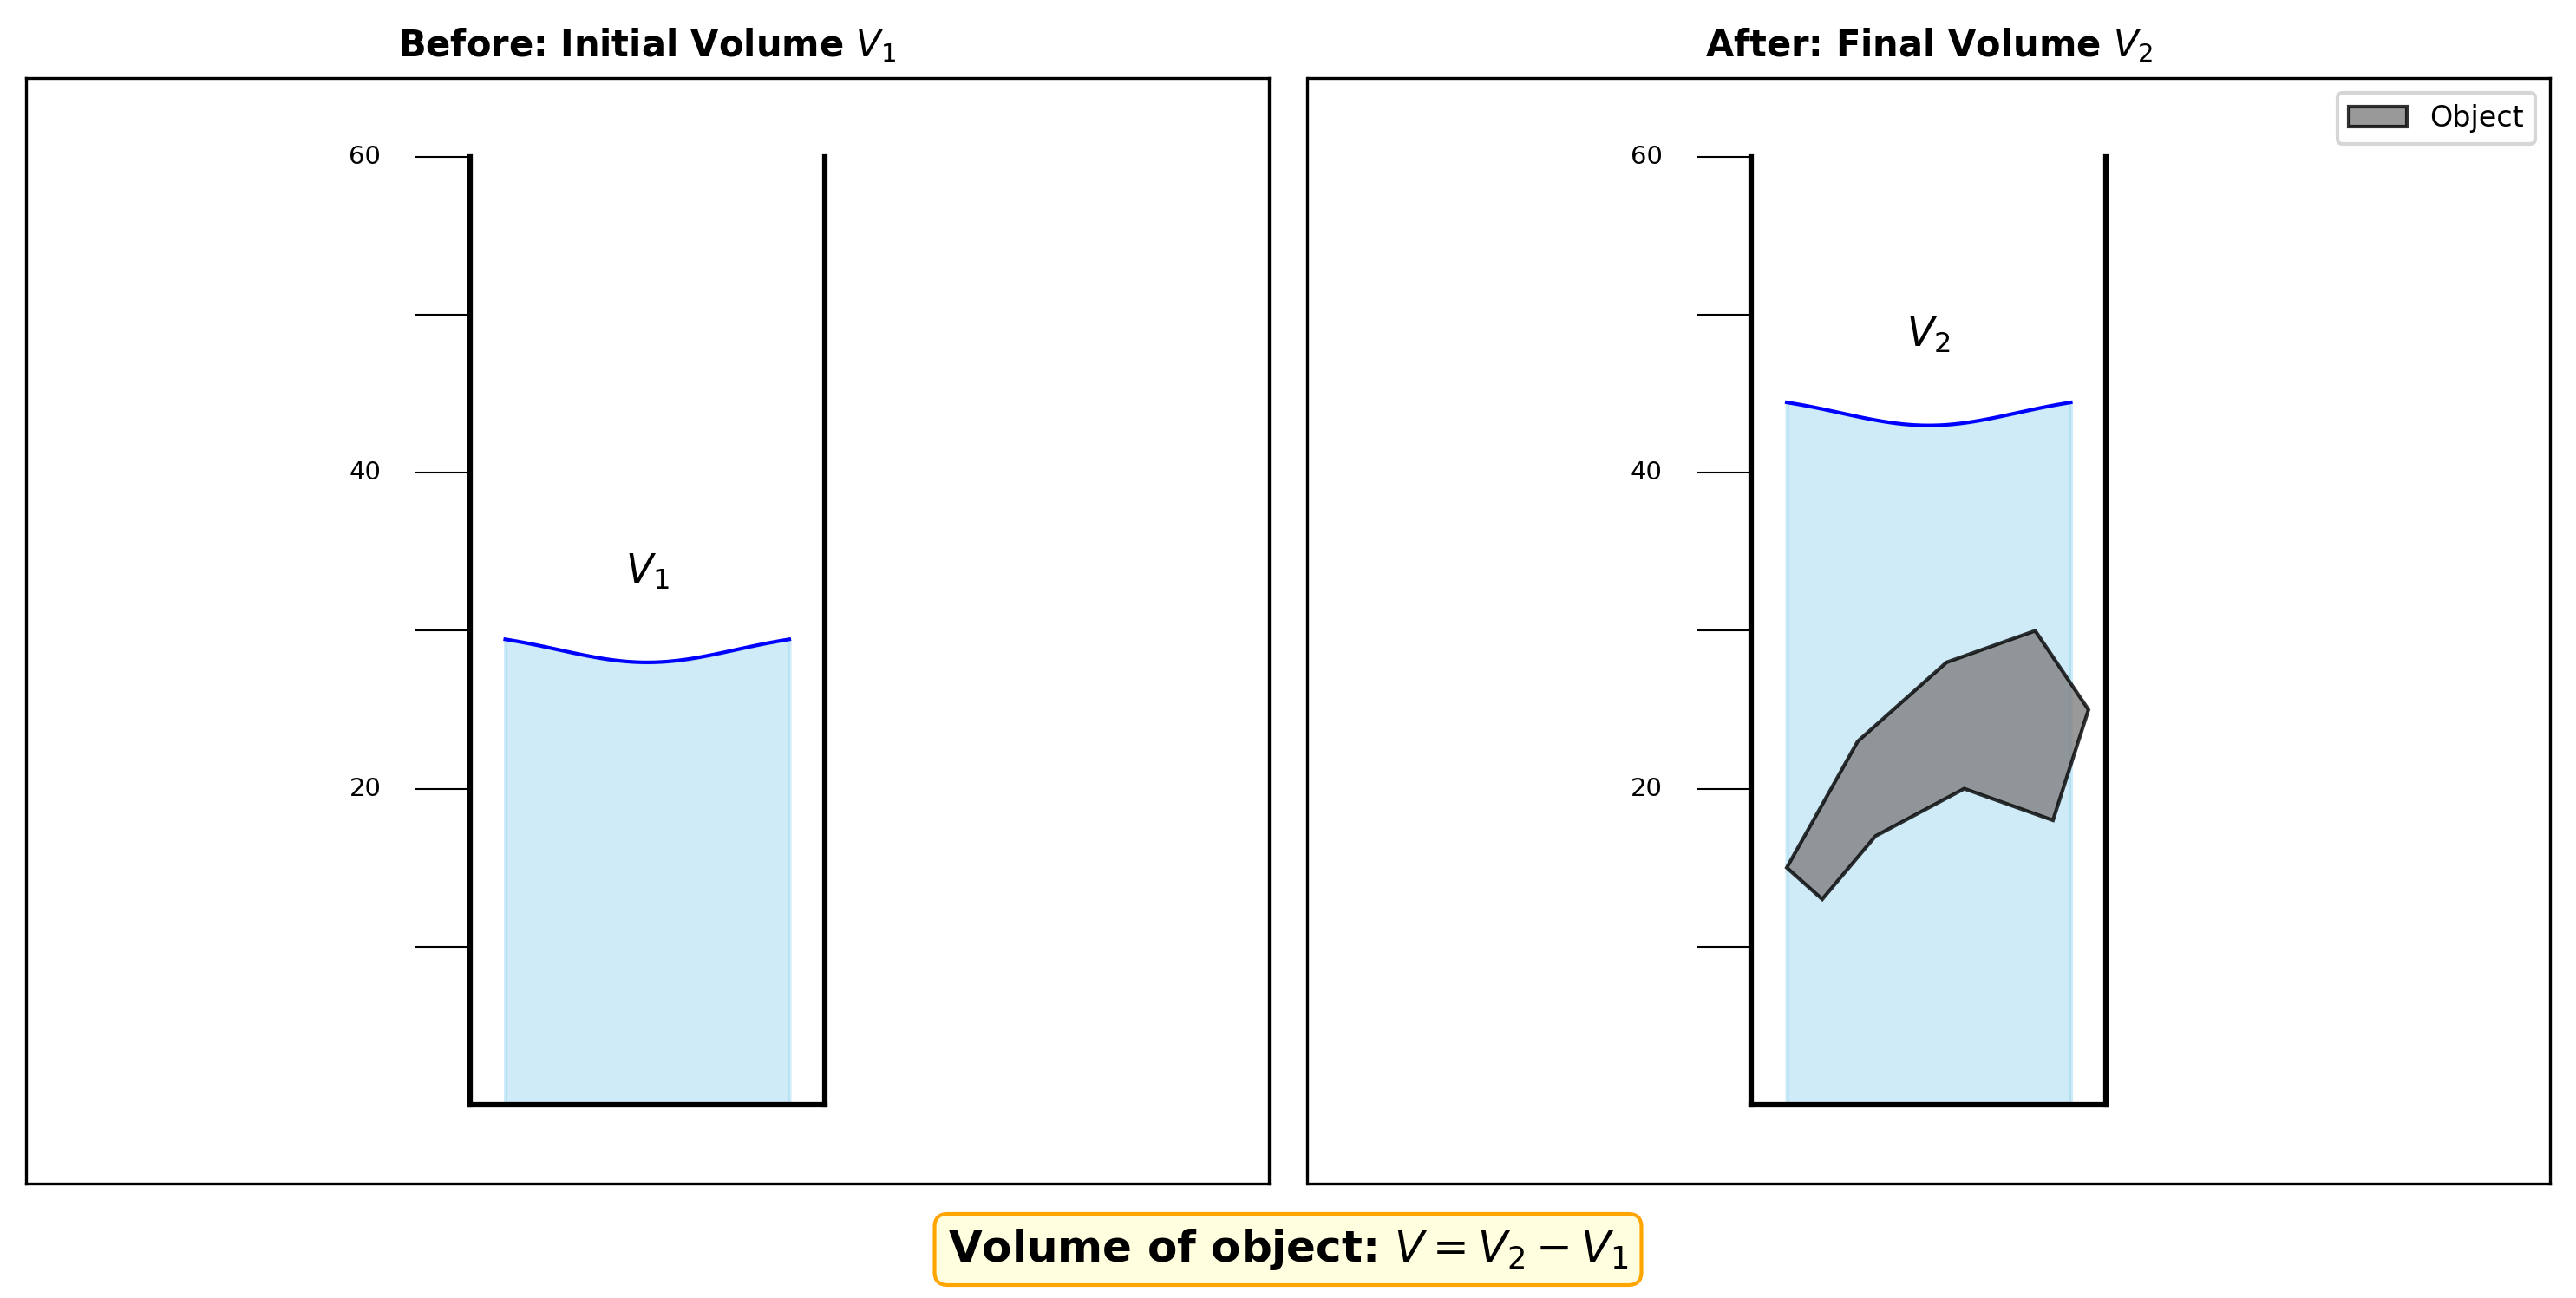

In [6]:
#| label: fig-displacement-method
#| fig-cap: Displacement method for measuring volume of irregular solids
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Cylinder dimensions
cyl_w = 2
cyl_h = 6

# Before immersion
ax1.plot([-cyl_w/2, -cyl_w/2], [0, cyl_h], 'k-', linewidth=1.5)
ax1.plot([cyl_w/2, cyl_w/2], [0, cyl_h], 'k-', linewidth=1.5)
ax1.plot([-cyl_w/2, cyl_w/2], [0, 0], 'k-', linewidth=1.5)

# Water level before
water_before = 3
x = np.linspace(-cyl_w/2 + 0.2, cyl_w/2 - 0.2, 50)
meniscus_before = water_before - 0.2 * np.exp(-((x)/0.7)**2)
ax1.fill_between(x, 0, meniscus_before, alpha=0.4, color='skyblue')
ax1.plot(x, meniscus_before, 'b-', linewidth=1)
ax1.text(0, water_before + 0.3, f'$V_1$', ha='center', fontsize=11, fontweight='bold')

# Add markings
for i in range(1, 7):
    ax1.plot([-cyl_w/2 - 0.3, -cyl_w/2], [i, i], 'k-', linewidth=0.5)
    if i % 2 == 0:
        ax1.text(-cyl_w/2 - 0.5, i, f'{i*10}', ha='right', va='center', fontsize=7)

ax1.set_title('Before: Initial Volume $V_1$', fontsize=10, fontweight='bold')
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-0.5, cyl_h + 0.5)
ax1.grid(axis='y', alpha=0.2, linestyle=':')
ax1.set_xticks([])
ax1.set_yticks([])

# After immersion
ax2.plot([-cyl_w/2, -cyl_w/2], [0, cyl_h], 'k-', linewidth=1.5)
ax2.plot([cyl_w/2, cyl_w/2], [0, cyl_h], 'k-', linewidth=1.5)
ax2.plot([-cyl_w/2, cyl_w/2], [0, 0], 'k-', linewidth=1.5)

# Water level after (higher)
water_after = 4.5
meniscus_after = water_after - 0.2 * np.exp(-((x)/0.7)**2)
ax2.fill_between(x, 0, meniscus_after, alpha=0.4, color='skyblue')
ax2.plot(x, meniscus_after, 'b-', linewidth=1)
ax2.text(0, water_after + 0.3, f'$V_2$', ha='center', fontsize=11, fontweight='bold')

# Draw irregular object submerged
object_x = np.array([-0.8, -0.6, -0.3, 0.2, 0.7, 0.9, 0.6, 0.1, -0.4, -0.8])
object_y = np.array([1.0, 0.8, 1.2, 1.5, 1.3, 2.0, 2.5, 2.3, 1.8, 1.0]) + 0.5
ax2.fill(object_x, object_y, color='gray', edgecolor='black', linewidth=1, alpha=0.8, label='Object')

# Add same markings
for i in range(1, 7):
    ax2.plot([-cyl_w/2 - 0.3, -cyl_w/2], [i, i], 'k-', linewidth=0.5)
    if i % 2 == 0:
        ax2.text(-cyl_w/2 - 0.5, i, f'{i*10}', ha='right', va='center', fontsize=7)

ax2.set_title('After: Final Volume $V_2$', fontsize=10, fontweight='bold')
ax2.set_xlim(-3.5, 3.5)
ax2.set_ylim(-0.5, cyl_h + 0.5)
ax2.grid(axis='y', alpha=0.2, linestyle=':')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.legend(fontsize=8, loc='upper right')

# Add formula annotation between plots
fig.text(0.5, 0.02, 'Volume of object: $V = V_2 - V_1$', 
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()